# Spoken Wiki attentional word recognition pilot task results

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


### Get model results

In [2]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
model_name = 'word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout'
# model_name = 'word_task_quarter_co_loc_v08'
# model_name = 'word_task_25p_loc_v07_LN_last_valid_time_no_affine'

output_paths = list(Path(f"time_reversed_eval/{model_name}").glob("*.pkl"))
# output_paths = list(Path(f"/om2/user/rphess/Auditory-Attention/binaural_eval/human_pilot_conds/{model_name}").glob("*.pkl"))


stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')

remap_azim = lambda azim: 360 - azim if azim > 90 else 0 - azim 

results_dfs = []

gend_map = {True:'Same sex', False:'Different sex'}

for path in output_paths:
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    
    df.rename(columns={"results": "accuracy"}, inplace=True)
    # merge with stim manifest
    df = df.join(stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')  
    df['Distractor Sex'] = df["gender"].values == df['bg_gender'].values
    df['Distractor Sex'] =  df['Distractor Sex'].map(gend_map)
    # map azim to 0-180
    df['snr'] = int(re.search('(-?\d+)SNR', path.stem).group(0).strip('SNR'))
    df['Distractor Playback'] = 'Time Reversed' if 'time_reversed' in path.stem else "Forward"

    
    results_dfs.append(df)
results = pd.concat(results_dfs)

In [3]:
results

,accuracy,confusions,preds,true_word_int,word,bg_word,gender,bg_gender,Distractor Sex,snr,Distractor Playback
0,1,0,135,135,commercial,hours,male,female,Different sex,-3,Forward
1,0,0,619,618,showed,british,male,female,Different sex,-3,Forward
2,0,0,541,693,technology,within,female,female,Same sex,-3,Forward
3,0,1,588,638,sound,river,female,female,Same sex,-3,Forward
4,0,1,420,381,lives,minutes,female,female,Same sex,-3,Forward
...,...,...,...,...,...,...,...,...,...,...,...
3151,0,0,434,329,including,common,male,male,Same sex,3,Time Reversed
3152,1,0,80,80,brother,council,male,male,Same sex,3,Time Reversed
3153,0,0,702,18,airport,catholic,male,male,Same sex,3,Time Reversed
3154,0,0,305,386,london,brown,male,male,Same sex,3,Time Reversed


In [4]:
melted_results = pd.melt(results, id_vars=['snr', 'Distractor Sex', 'Distractor Playback'],
        value_vars=['accuracy', 'confusions'],
        value_name = 'hits',
        var_name = 'stream')

In [5]:
melted_results.stream.replace({"accuracy": "Accuracy", "confusions": "Confusions"}, inplace=True)


## Line plots

Text(0.5, 1.05, 'Using 1 disractor at 0 dB SNR\nFeature-gain Model')

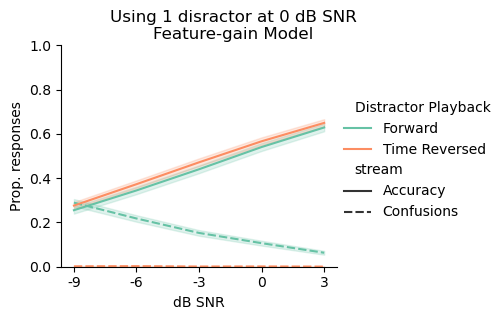

In [10]:
# results = all_results[all_results.snr.isin([0.25, 0.5,1,2])]


# group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Model']
# add markers to relplot
g = sns.relplot(data=melted_results, x='snr', y='hits', # hue='gender_cond',
                # col_wrap=3,
                # hue='Distractor Sex', #
                style='stream',
                hue='Distractor Playback', #style_order = ['Forward', 'Time Reversed'],
                kind='line', marker='',
                # color='k',
                palette='Set2',
                height=3, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. responses")
# g.set_titles("{col_name}")

# add xtick labels 
value_tick = results.snr.unique()
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=value_tick) # set new labels
    ax.set_xticklabels(value_tick)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR\nFeature-gain Model", y=1.05)


(0.0, 1.0)

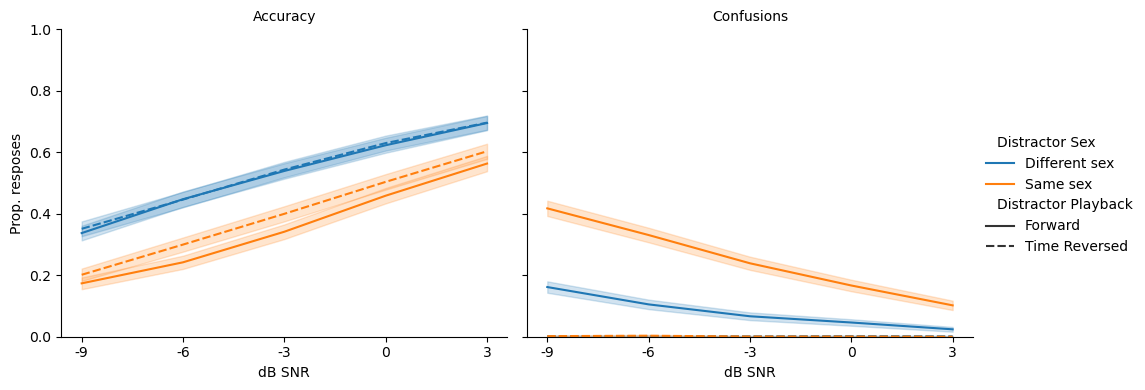

In [11]:
# results = all_results[all_results.snr.isin([0.25, 0.5,1,2])]


# group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Model']
# add markers to relplot
g = sns.relplot(data=melted_results, x='snr', y='hits', # hue='gender_cond',
                # col_wrap=3,
                hue='Distractor Sex', #
                col='stream',
                style='Distractor Playback', style_order = ['Forward', 'Time Reversed'],
                kind='line', marker='',
                # color='k',
                height=4, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. resposes")
g.set_titles("{col_name}")

# add xtick labels 
value_tick = results.snr.unique()
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=value_tick) # set new labels
    ax.set_xticklabels(value_tick)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())

plt.ylim(0,1)
# plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)
